# ĐỒ ÁN KHAI PHÁ DỮ LIỆU
## Predict Students' Dropout and Academic Success

### Sinh viên thực hiện
- Nguyễn Dương Bảo Trân - 3123410386
- Giang Hào Tường - 3123410421

### Bài toán 2
Dự đoán kết quả học tập của sinh viên thuộc 1 trong 3 nhóm:
- Dropout
- Enrolled
- Graduate

### Hai câu hỏi khai phá dữ liệu
1. Những yếu tố nào ảnh hưởng nhiều nhất đến tình trạng học tập của sinh viên?
2. Có thể xây dựng mô hình dự đoán kết quả học tập của sinh viên đủ tốt để hỗ trợ nhà trường hay không?

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Đã import xong thư viện.")

Đã import xong thư viện.


### 1. Đọc dữ liệu và xem thông tin tổng quan

In [2]:
file_path = "data.csv"

df = pd.read_csv(file_path)

# nếu đọc ra 1 cột thì thử lại với dấu ;
if df.shape[1] == 1:
    df = pd.read_csv(file_path, sep=";")

print("Kích thước dữ liệu:", df.shape)
display(df.head())
df.info()
display(df.describe(include="all").T)

Kích thước dữ liệu: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance\t,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


### 2. Kiểm tra dữ liệu thiếu, dữ liệu trùng lặp và phân bố biến mục tiêu ban đầu

In [3]:
print("Số lượng giá trị thiếu theo từng cột:")
display(df.isnull().sum())

print("Số dòng trùng lặp:", df.duplicated().sum())

target_col = "Target" if "Target" in df.columns else df.columns[-1]

print("Tên cột mục tiêu:", target_col)
print("Phân bố biến mục tiêu:")
display(df[target_col].value_counts())
display((df[target_col].value_counts(normalize=True) * 100).round(2))

Số lượng giá trị thiếu theo từng cột:


Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

Số dòng trùng lặp: 0
Tên cột mục tiêu: Target
Phân bố biến mục tiêu:


Graduate    2209
Dropout     1421
Enrolled     794
Name: Target, dtype: int64

Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: Target, dtype: float64

### 3. Tiền xử lý dữ liệu: chuẩn hóa tên cột và làm sạch dữ liệu

In [4]:
data = df.copy()

data.columns = [
    col.strip()
       .lower()
       .replace("'", "")
       .replace("/", "_")
       .replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
       .replace("-", "_")
    for col in data.columns
]

print("Tên cột sau khi chuẩn hóa:")
print(data.columns.tolist())

print("Số dòng trùng lặp trước khi xóa:", data.duplicated().sum())
data = data.drop_duplicates().copy()
print("Kích thước dữ liệu sau khi xóa trùng:", data.shape)

display(data.head())

Tên cột sau khi chuẩn hóa:
['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mothers_qualification', 'fathers_qualification', 'mothers_occupation', 'fathers_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp', 'target']
Số dòng trùng lặ

,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mothers_qualification,fathers_qualification,mothers_occupation,fathers_occupation,admission_grade,displaced,educational_special_needs,debtor,tuition_fees_up_to_date,gender,scholarship_holder,age_at_enrollment,international,curricular_units_1st_sem_credited,curricular_units_1st_sem_enrolled,curricular_units_1st_sem_evaluations,curricular_units_1st_sem_approved,curricular_units_1st_sem_grade,curricular_units_1st_sem_without_evaluations,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### 4. Xác định biến mục tiêu và tách dữ liệu mô hình

In [5]:
target_column = "target"

print("Các lớp của biến mục tiêu:")
display(data[target_column].value_counts())

X = data.drop(columns=[target_column])
y = data[target_column]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Các lớp của biến mục tiêu:


Graduate    2209
Dropout     1421
Enrolled     794
Name: target, dtype: int64

Kích thước X: (4424, 36)
Kích thước y: (4424,)


### 5. Thống kê mô tả sau tiền xử lý

In [6]:
display(X.describe(include="all").T)

print("Phân bố target:")
display((y.value_counts(normalize=True) * 100).round(2))

,count,mean,std,min,25%,50%,75%,max
marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


Phân bố target:


Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: target, dtype: float64

### 6. Phân tích đơn biến

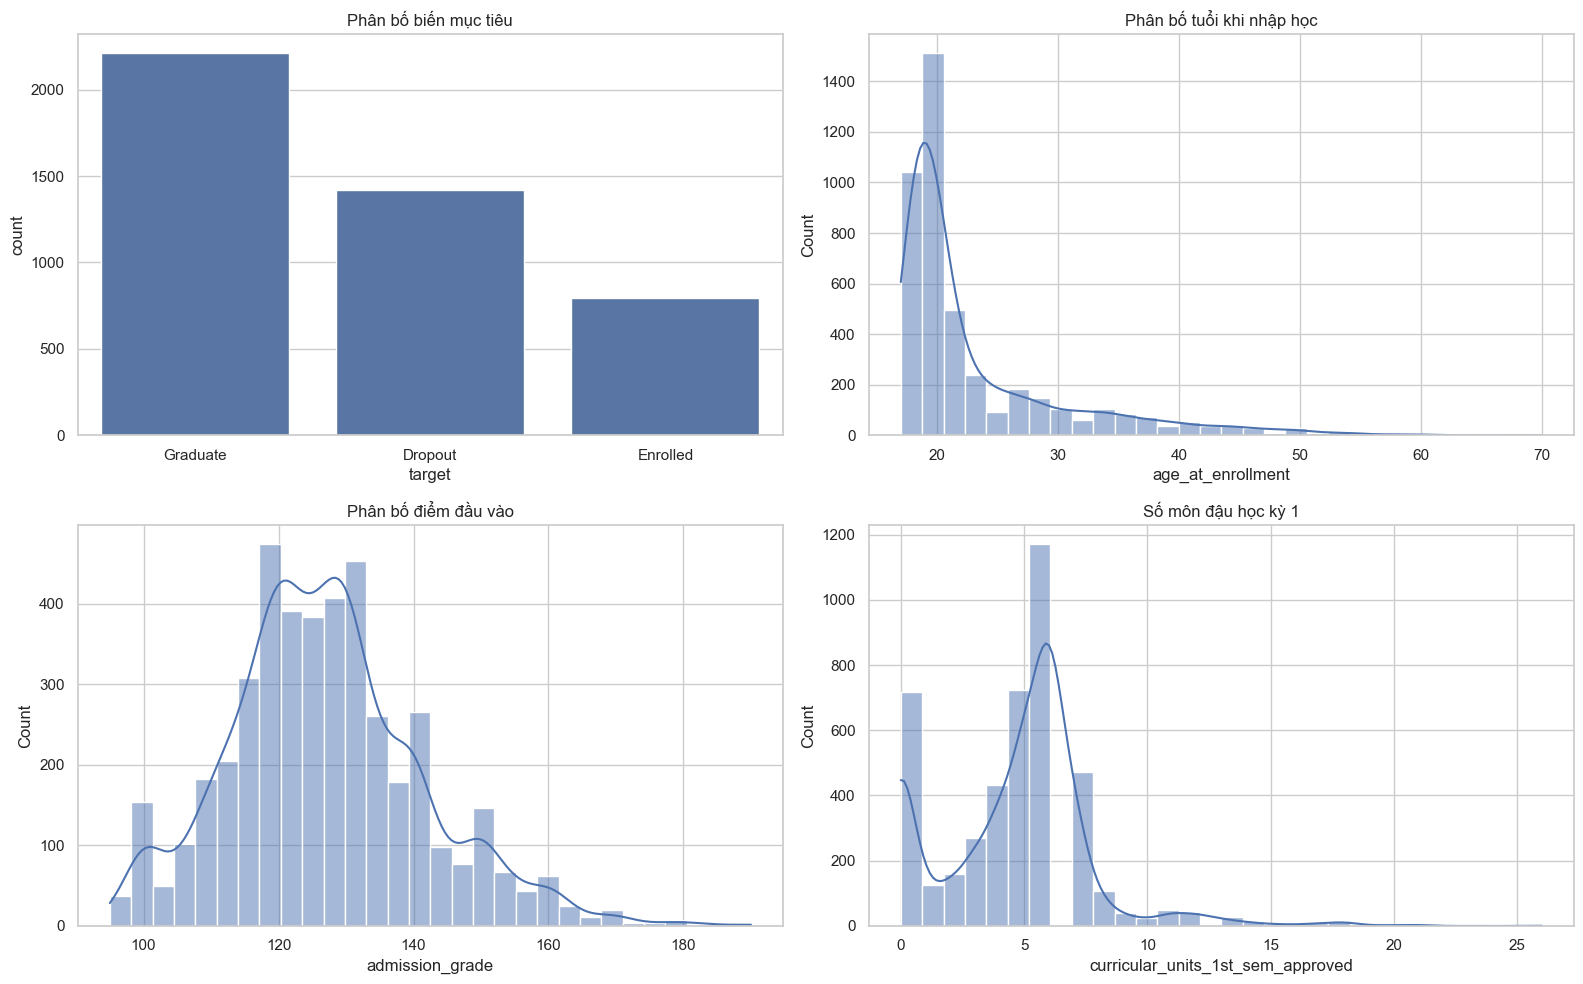

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(x=y, order=y.value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Phân bố biến mục tiêu")

if "age_at_enrollment" in data.columns:
    sns.histplot(data["age_at_enrollment"], bins=30, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title("Phân bố tuổi khi nhập học")

if "admission_grade" in data.columns:
    sns.histplot(data["admission_grade"], bins=30, kde=True, ax=axes[1, 0])
    axes[1, 0].set_title("Phân bố điểm đầu vào")

if "curricular_units_1st_sem_approved" in data.columns:
    sns.histplot(data["curricular_units_1st_sem_approved"], bins=30, kde=True, ax=axes[1, 1])
    axes[1, 1].set_title("Số môn đậu học kỳ 1")

plt.tight_layout()
plt.show()

### 7. Phân tích đa biến

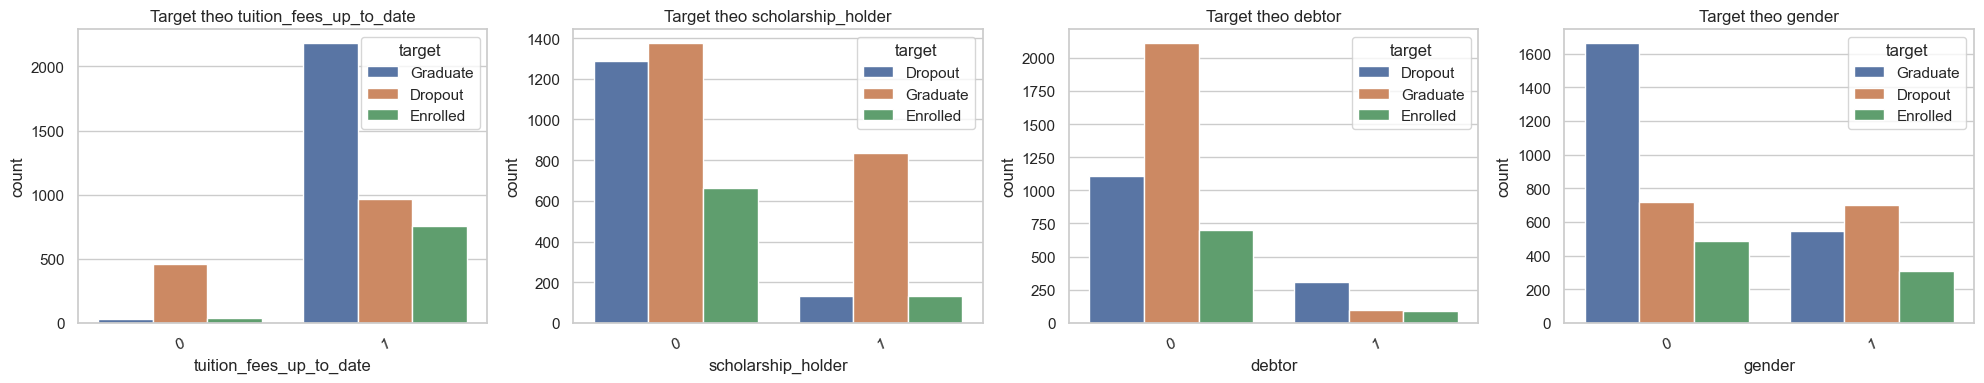

In [8]:
plot_cols = [
    "tuition_fees_up_to_date",
    "scholarship_holder",
    "debtor",
    "gender"
]

existing_plot_cols = [col for col in plot_cols if col in data.columns]

if len(existing_plot_cols) > 0:
    fig, axes = plt.subplots(1, len(existing_plot_cols), figsize=(5 * len(existing_plot_cols), 4))
    
    if len(existing_plot_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, existing_plot_cols):
        sns.countplot(data=data, x=col, hue="target", ax=ax)
        ax.set_title(f"Target theo {col}")
        ax.tick_params(axis="x", rotation=20)
    
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy các cột để vẽ countplot theo target.")

### 8. Ma trận tương quan giữa các biến số

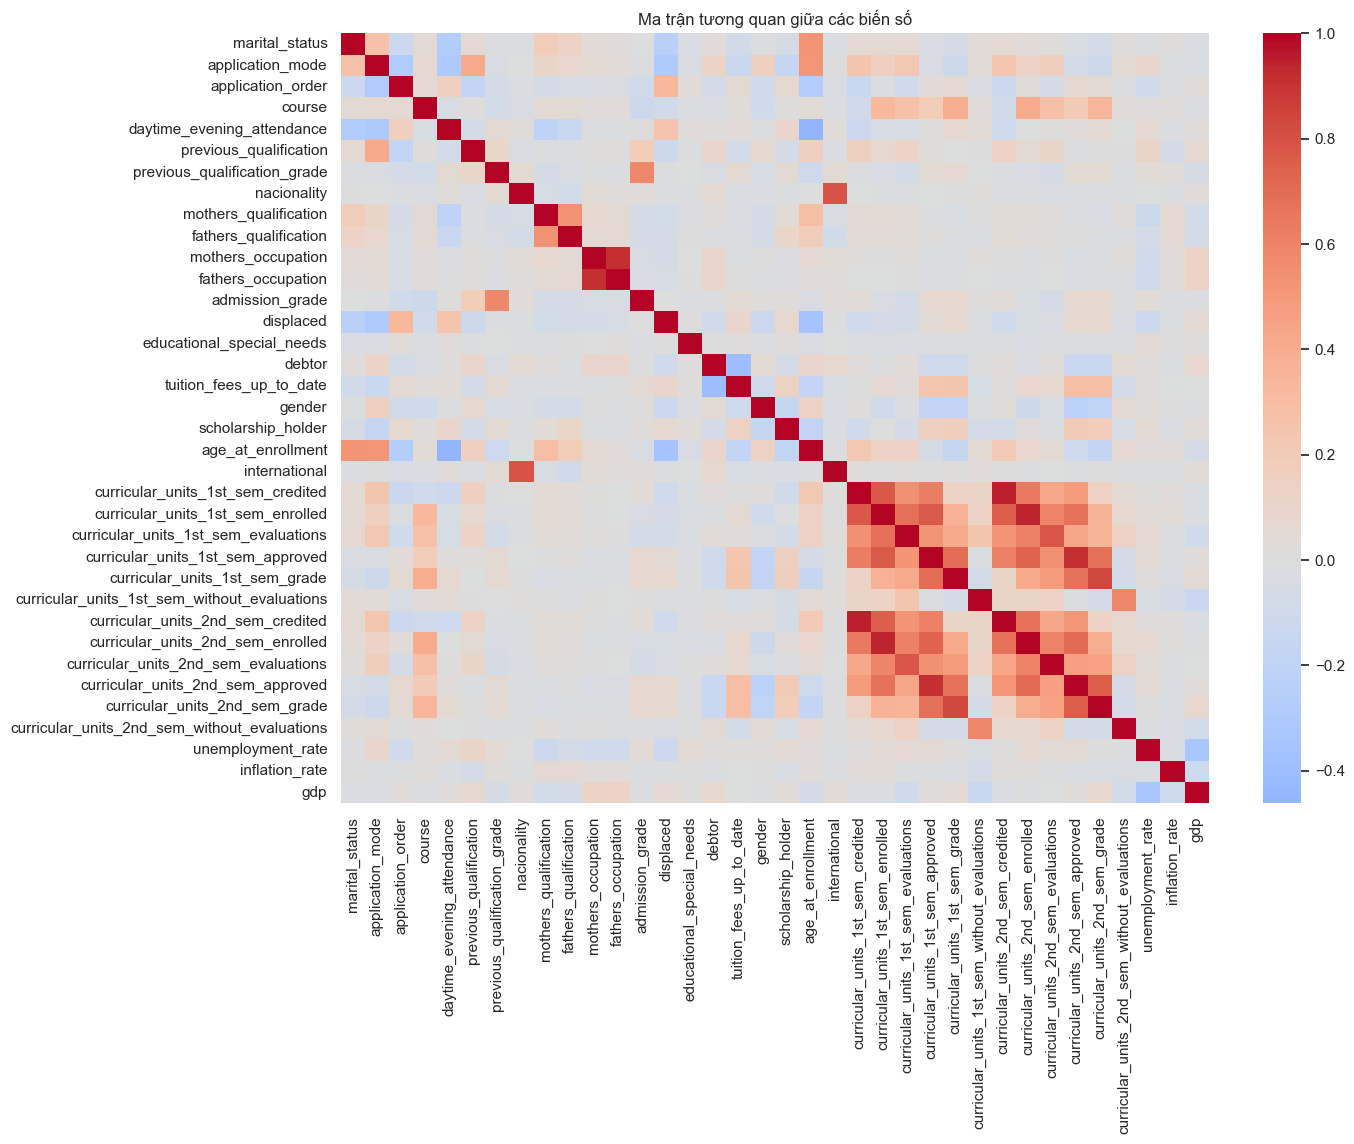

In [9]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(data[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

### 9. Chia dữ liệu train và test, xây dựng pipeline tiền xử lý

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test :", X_test.shape)
print("Biến số:", numeric_features)
print("Biến phân loại:", categorical_features)

Kích thước X_train: (3539, 36)
Kích thước X_test : (885, 36)
Biến số: ['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mothers_qualification', 'fathers_qualification', 'mothers_occupation', 'fathers_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflati

### 10. Khởi tạo các mô hình phân loại

In [11]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    )
}

def evaluate_multiclass_model(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    }
    
    y_prob = None
    if hasattr(pipe.named_steps["classifier"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)
        classes = pipe.named_steps["classifier"].classes_
        y_test_bin = label_binarize(y_test, classes=classes)
        result["ROC_AUC_OVR_weighted"] = roc_auc_score(
            y_test_bin, y_prob, multi_class="ovr", average="weighted"
        )
    else:
        result["ROC_AUC_OVR_weighted"] = np.nan
    
    return pipe, y_pred, y_prob, result

print("Đã khởi tạo xong các mô hình.")

Đã khởi tạo xong các mô hình.


### 11. Huấn luyện và so sánh các mô hình

In [12]:
trained_models = {}
results = []

for name, model in models.items():
    pipe, y_pred, y_prob, result = evaluate_multiclass_model(
        name, model, X_train, X_test, y_train, y_test
    )
    trained_models[name] = {
        "pipeline": pipe,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    results.append(result)

results_df = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_OVR_weighted
0,Random Forest,0.751412,0.710199,0.707233,0.704368,0.756420,0.903821
1,Logistic Regression,0.728814,0.704922,0.704734,0.692742,0.743413,0.895595
2,Decision Tree,0.670056,0.656804,0.653519,0.639356,0.686725,0.810525


### 12. Chọn mô hình tốt nhất và đánh giá chi tiết

Mô hình tốt nhất: Random Forest

              precision    recall  f1-score   support

     Dropout       0.83      0.69      0.75       284
    Enrolled       0.46      0.58      0.51       159
    Graduate       0.84      0.85      0.85       442

    accuracy                           0.75       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.77      0.75      0.76       885



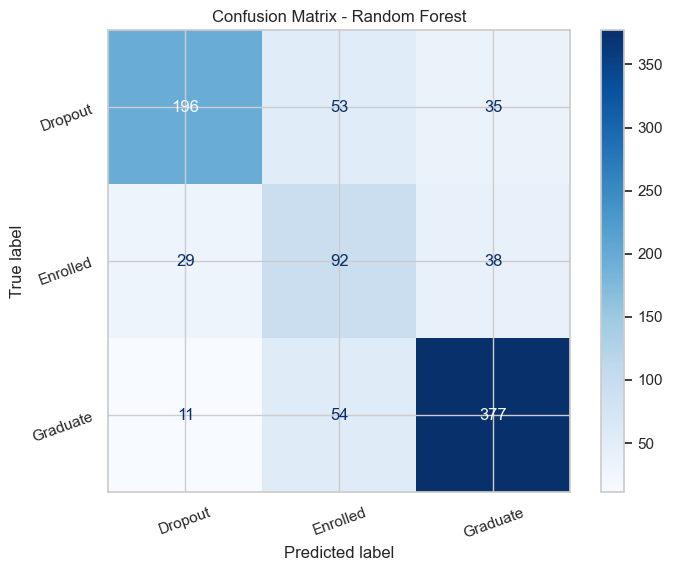

In [13]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]["pipeline"]
best_pred = trained_models[best_model_name]["y_pred"]

print("Mô hình tốt nhất:", best_model_name)
print()
print(classification_report(y_test, best_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xticks(rotation=20)
plt.yticks(rotation=20)
plt.show()

### 13. Phân tích mức độ ảnh hưởng của các thuộc tính

,Feature,Importance
30,num__curricular_units_2nd_sem_approved,0.164584
31,num__curricular_units_2nd_sem_grade,0.108568
24,num__curricular_units_1st_sem_approved,0.094579
25,num__curricular_units_1st_sem_grade,0.062857
16,num__tuition_fees_up_to_date,0.054766
29,num__curricular_units_2nd_sem_evaluations,0.046814
23,num__curricular_units_1st_sem_evaluations,0.041554
19,num__age_at_enrollment,0.040135
12,num__admission_grade,0.034946
3,num__course,0.029073


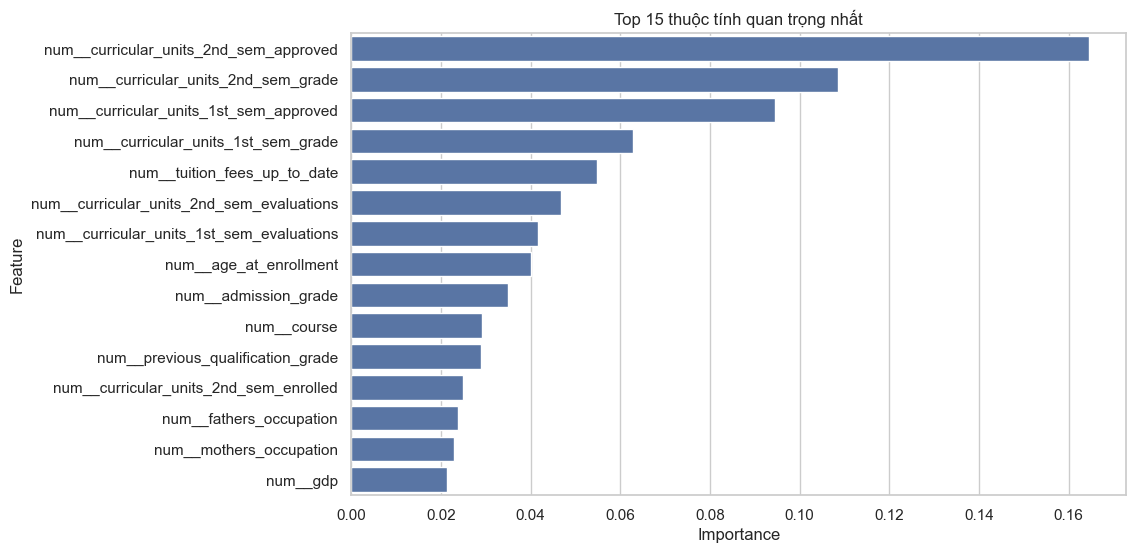

In [14]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

if best_model_name in ["Decision Tree", "Random Forest"]:
    importances = best_model.named_steps["classifier"].feature_importances_
    feat_imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    display(feat_imp.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp.head(15), x="Importance", y="Feature")
    plt.title("Top 15 thuộc tính quan trọng nhất")
    plt.show()

elif best_model_name == "Logistic Regression":
    coef = best_model.named_steps["classifier"].coef_
    avg_abs_coef = np.mean(np.abs(coef), axis=0)

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": avg_abs_coef
    }).sort_values(by="Importance", ascending=False)

    display(coef_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(15), x="Importance", y="Feature")
    plt.title("Top 15 thuộc tính có ảnh hưởng lớn nhất")
    plt.show()

### 14. Trả lời câu hỏi khai phá dữ liệu

**Câu hỏi 1: Những yếu tố nào ảnh hưởng nhiều nhất đến tình trạng học tập của sinh viên?**  
Dựa trên kết quả phân tích khám phá dữ liệu và phần phân tích mức độ quan trọng của thuộc tính từ mô hình tốt nhất, có thể thấy tình trạng học tập của sinh viên chịu ảnh hưởng đáng kể bởi một số nhóm yếu tố như: tình trạng đóng học phí, học bổng, số môn đạt ở học kỳ 1 và học kỳ 2, điểm đầu vào, cũng như một số đặc điểm cá nhân và học tập khác.  
Nhìn chung, các biến liên quan đến **kết quả học tập trong năm nhất** và **điều kiện tài chính/học vụ** là những yếu tố có ảnh hưởng rõ rệt đến khả năng sinh viên rơi vào nhóm Dropout, Enrolled hoặc Graduate.  
Để kết luận chính xác biến nào ảnh hưởng mạnh nhất, cần dựa vào biểu đồ **Top feature** ở phần trên.

**Câu hỏi 2: Có thể xây dựng mô hình dự đoán kết quả học tập của sinh viên đủ tốt để hỗ trợ nhà trường hay không?**  
Dựa trên kết quả thực nghiệm, mô hình tốt nhất là **Random Forest** với các chỉ số:
- Accuracy = **0.751412**
- Precision_macro = **0.710199**
- Recall_macro = **0.707233**
- F1_macro = **0.704368**
- F1_weighted = **0.756420**
- ROC_AUC_OVR_weighted = **0.903821**

So với hai mô hình còn lại, Random Forest cho kết quả tốt nhất trên hầu hết các chỉ số đánh giá, đặc biệt là **F1_macro** và **ROC_AUC_OVR_weighted**. Điều này cho thấy mô hình có khả năng phân biệt khá tốt giữa ba nhóm sinh viên: **Dropout**, **Enrolled** và **Graduate**.  

Vì vậy, có thể kết luận rằng bài toán dự đoán kết quả học tập của sinh viên là **khả thi**. Mô hình Random Forest có thể hỗ trợ nhà trường trong việc nhận diện sớm sinh viên có nguy cơ bỏ học hoặc học tập không ổn định, từ đó đưa ra các biện pháp hỗ trợ phù hợp.

In [15]:
results_df.to_csv("student_model_comparison_results.csv", index=False)
print("Đã lưu file student_model_comparison_results.csv")
results_df

Đã lưu file student_model_comparison_results.csv


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_OVR_weighted
0,Random Forest,0.751412,0.710199,0.707233,0.704368,0.756420,0.903821
1,Logistic Regression,0.728814,0.704922,0.704734,0.692742,0.743413,0.895595
2,Decision Tree,0.670056,0.656804,0.653519,0.639356,0.686725,0.810525


### 15. Kết luận tạm thời

Trong notebook này, bộ dữ liệu Predict Students' Dropout and Academic Success đã được xử lý và phân tích để phục vụ bài toán phân loại đa lớp.  
Các bước chính bao gồm:
- kiểm tra và làm sạch dữ liệu,
- phân tích thống kê mô tả,
- phân tích đơn biến và đa biến,
- xây dựng nhiều mô hình phân loại,
- đánh giá kết quả và lựa chọn mô hình phù hợp.

Kết quả của notebook là cơ sở để tiếp tục hoàn thiện báo cáo cuối kỳ và đề xuất các giải pháp hỗ trợ sinh viên có nguy cơ bỏ học.